In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../data/Food demand.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1999, 9)


In [4]:
df.head()


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1000000,3,157,2760,233.83,231.83,0,0,149
1,1000001,100,104,2956,486.03,583.03,0,0,161
2,1000002,143,75,1971,328.86,327.86,0,0,149
3,1000003,41,24,2539,145.53,145.53,0,0,540
4,1000004,45,83,2539,95.06,120.34,0,0,271


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1999 non-null   int64  
 1   week                   1999 non-null   int64  
 2   center_id              1999 non-null   int64  
 3   meal_id                1999 non-null   int64  
 4   checkout_price         1999 non-null   float64
 5   base_price             1999 non-null   float64
 6   emailer_for_promotion  1999 non-null   int64  
 7   homepage_featured      1999 non-null   int64  
 8   num_orders             1999 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.7 KB


In [6]:
df.isnull().sum()

id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64

In [7]:
df.describe()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,1.999000e+03,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,1.001093e+06,75.393197,81.649825,2010.123562,327.302596,347.972866,0.076538,0.105053,258.340170
std,6.323493e+02,41.743802,46.139173,554.686525,150.906902,158.625091,0.265924,0.306698,413.743045
min,1.000000e+06,1.000000,10.000000,1062.000000,65.020000,93.120000,0.000000,0.000000,13.000000
25%,1.000546e+06,40.000000,43.000000,1543.000000,222.645000,242.530000,0.000000,0.000000,55.000000
50%,1.001094e+06,78.000000,76.000000,1971.000000,292.030000,309.430000,0.000000,0.000000,148.000000
75%,1.001638e+06,111.500000,110.000000,2539.000000,435.530000,447.230000,0.000000,0.000000,324.000000
max,1.002181e+06,145.000000,186.000000,2956.000000,767.330000,767.330000,1.000000,1.000000,12137.000000


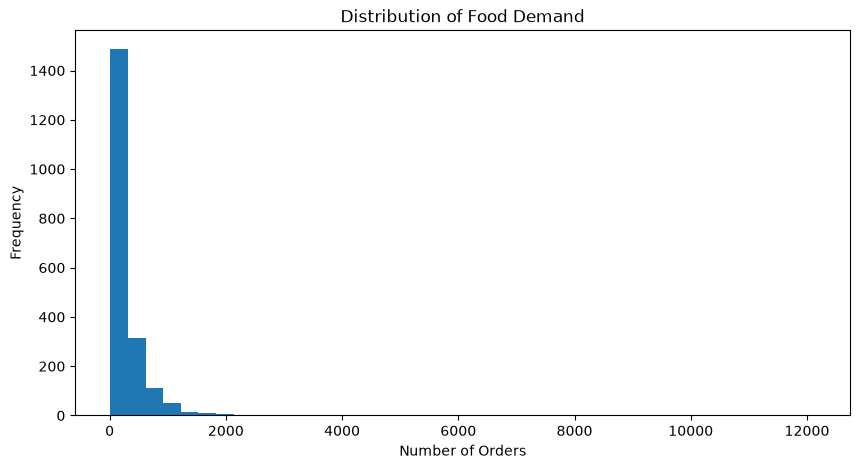

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(df["num_orders"], bins=40)

plt.title("Distribution of Food Demand")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_25192\1800061926.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["num_orders"], vert=False)


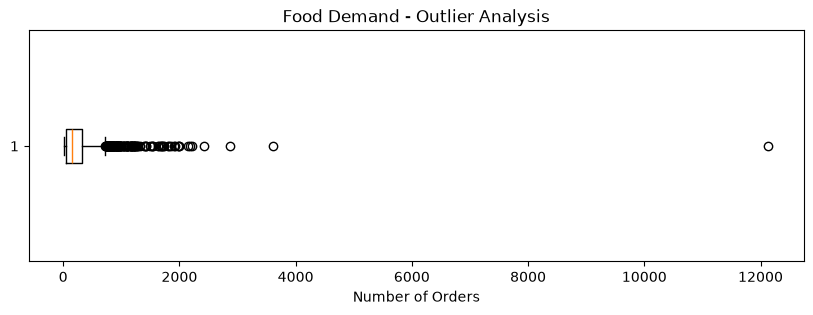

In [9]:
plt.figure(figsize=(10, 3))

plt.boxplot(df["num_orders"], vert=False)

plt.title("Food Demand - Outlier Analysis")
plt.xlabel("Number of Orders")

plt.show()

In [10]:
print("Average Demand:", round(df["num_orders"].mean(), 2))
print("Median Demand:", df["num_orders"].median())
print("Minimum Demand:", df["num_orders"].min())
print("Maximum Demand:", df["num_orders"].max())

Average Demand: 258.34
Median Demand: 148.0
Minimum Demand: 13
Maximum Demand: 12137


### EDA Observation – Food Demand Distribution

The food demand distribution is highly right-skewed, with most observations concentrated at lower order values. A small number of observations have significantly higher demand and appear as potential outliers in the box plot.

These high-demand observations will be investigated further before deciding whether any treatment is required. They will not be removed automatically because they may represent genuine high-demand situations.


In [11]:
promotion_demand = df.groupby("emailer_for_promotion")["num_orders"].mean()

print(promotion_demand)

emailer_for_promotion
0    226.624052
1    641.006536
Name: num_orders, dtype: float64


In [12]:
homepage_demand = df.groupby("homepage_featured")["num_orders"].mean()

print(homepage_demand)

homepage_featured
0    220.262158
1    582.728571
Name: num_orders, dtype: float64


### EDA Observation – Promotional Features

The analysis shows that records with email promotion have a higher average number of orders compared with records without email promotion.

Similarly, meals featured on the homepage have a higher average number of orders than meals without homepage featuring.

These features may provide useful information for food-demand forecasting. However, the observed difference represents an association and does not by itself establish a causal relationship.

In [13]:
meal_demand = df.groupby("meal_id")["num_orders"].agg(["mean", "count"]).sort_values("mean", ascending=False)

meal_demand.head(10)

,mean,count
meal_id,,
2290,974.818182,55
1993,611.434783,46
1885,578.054545,55
1754,562.448980,49
1109,475.064516,62
1971,449.226415,53
2826,436.740741,54
1727,424.816327,49
2664,417.258065,31


In [14]:
center_demand = df.groupby("center_id")["num_orders"].agg(["mean", "count"]).sort_values("mean", ascending=False)

center_demand.head(10)

,mean,count
center_id,,
99,877.807692,26
13,594.772727,22
10,572.333333,30
174,481.800000,30
137,470.960000,25
43,442.343750,32
65,430.851852,27
52,349.333333,33
108,344.521739,23


### EDA Observation – Meal and Center Demand

Food demand varies considerably across different meal IDs and fulfillment centers.

Some meal IDs show substantially higher average demand than others. Similarly, certain centers have higher average order volumes compared with other centers.

Therefore, meal ID and center ID are considered potentially useful features for the food-demand forecasting model.

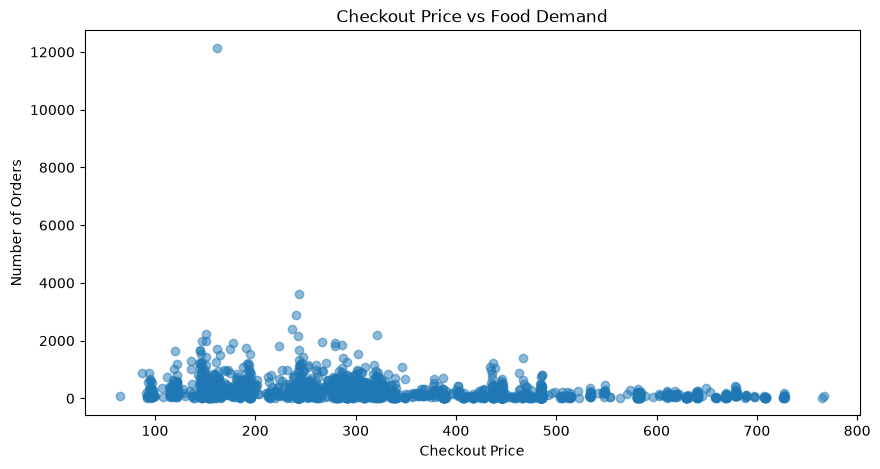

In [15]:
plt.figure(figsize=(10, 5))

plt.scatter(df["checkout_price"], df["num_orders"], alpha=0.5)

plt.title("Checkout Price vs Food Demand")
plt.xlabel("Checkout Price")
plt.ylabel("Number of Orders")

plt.show()

In [16]:
print(df[["checkout_price", "base_price", "num_orders"]].corr())

                checkout_price  base_price  num_orders
checkout_price        1.000000    0.952669   -0.232036
base_price            0.952669    1.000000   -0.169653
num_orders           -0.232036   -0.169653    1.000000


### EDA Observation – Price and Food Demand

The correlation analysis shows a weak negative relationship between price and food demand. The correlation between checkout price and number of orders is -0.232, while the correlation between base price and number of orders is -0.170.

This suggests that higher prices are generally associated with lower demand, although the relationship is not strong. Therefore, price-related features will be retained for further model development.

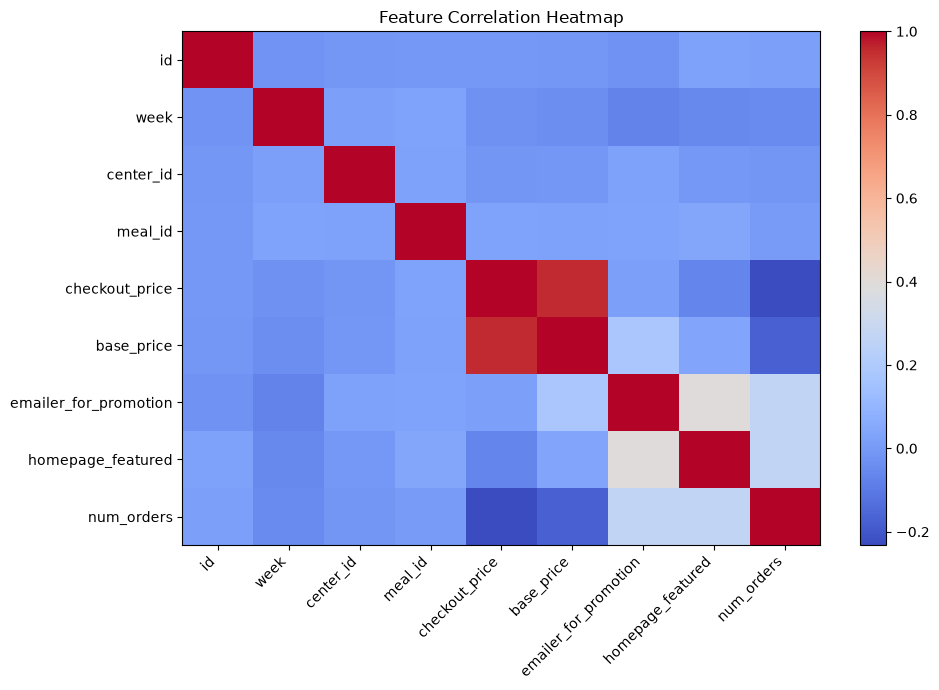

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

### EDA Observation – Correlation Analysis

The correlation analysis shows that checkout price and base price have a strong positive relationship with each other.

Both price features show a weak negative relationship with food demand. Promotional features show some positive association with the number of orders.

The ID column is an identifier rather than a meaningful demand-related feature and will not be used for model training.

In [18]:
df["week_sin"] = np.sin(2 * np.pi * df["week"] / 145)
df["week_cos"] = np.cos(2 * np.pi * df["week"] / 145)

df[["week", "week_sin", "week_cos"]].head()

,week,week_sin,week_cos
0,3,0.129631,0.991562
1,100,-0.928977,-0.370138
2,143,-0.086556,0.996247
3,41,0.978892,-0.204378
4,45,0.928977,-0.370138


In [19]:
df = df.drop(columns=["id"])

print("Updated shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Updated shape: (1999, 10)
Columns:
['week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'week_sin', 'week_cos']


In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [21]:
print("Unique centers:", df["center_id"].nunique())
print("Unique meals:", df["meal_id"].nunique())
print("Unique weeks:", df["week"].nunique())

Unique centers: 77
Unique meals: 51
Unique weeks: 145


In [22]:
print("Target missing values:", df["num_orders"].isnull().sum())
print("Target values <= 0:", (df["num_orders"] <= 0).sum())

Target missing values: 0
Target values <= 0: 0


In [23]:
X = df.drop(columns=["num_orders"])
y = df["num_orders"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1999, 9)
Target shape: (1999,)


In [24]:
split_week = int(df["week"].max() * 0.8)

train_df = df[df["week"] <= split_week].copy()
test_df = df[df["week"] > split_week].copy()

X_train = train_df.drop(columns=["num_orders"])
y_train = train_df["num_orders"]

X_test = test_df.drop(columns=["num_orders"])
y_test = test_df["num_orders"]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training weeks:", train_df["week"].min(), "to", train_df["week"].max())
print("Testing weeks:", test_df["week"].min(), "to", test_df["week"].max())

Training samples: 1572
Testing samples: 427
Training weeks: 1 to 116
Testing weeks: 117 to 145


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["center_id", "meal_id"]
numeric_features = [
    "week",
    "checkout_price",
    "base_price",
    "emailer_for_promotion",
    "homepage_featured",
    "week_sin",
    "week_cos"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (1572, 135)
Encoded testing shape: (427, 135)


In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_encoded, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [28]:
y_pred = model.predict(X_test_encoded)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[223.39333333  82.74333333 863.32666667  92.39       176.77333333
  66.65       105.58666667 109.06333333 289.40333333 780.32666667]


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Model Performance
------------------
MAE : 129.57
RMSE: 216.5
R²  : 0.4974


## Initial Model Results

A Random Forest Regressor was trained using the prepared features. The model achieved an MAE of 129.57, an RMSE of 216.50, and an R² score of 0.4974 on the time-based test set.

These results provide a baseline for food-demand forecasting. Further feature engineering and model tuning can be explored to improve prediction performance.

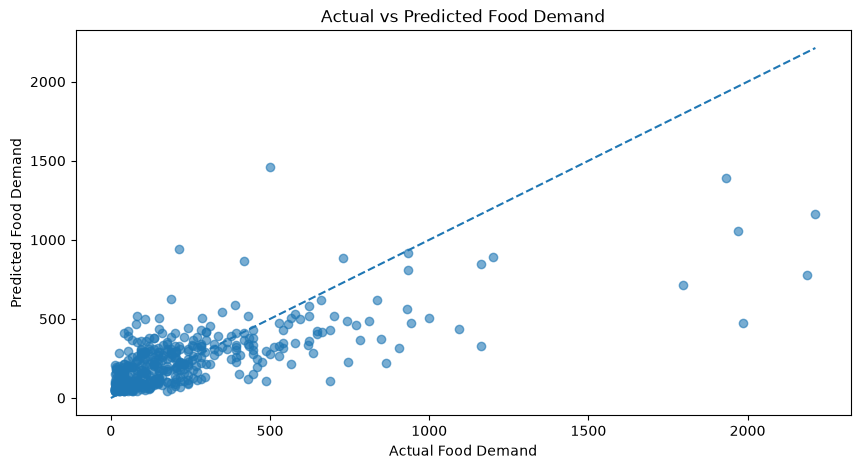

In [30]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Food Demand")
plt.ylabel("Predicted Food Demand")
plt.title("Actual vs Predicted Food Demand")

max_value = max(y_test.max(), y_pred.max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

plt.show()

In [31]:
from sklearn.ensemble import ExtraTreesRegressor

extra_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train_encoded, y_train)

extra_pred = extra_model.predict(X_test_encoded)

extra_mae = mean_absolute_error(y_test, extra_pred)
extra_rmse = np.sqrt(mean_squared_error(y_test, extra_pred))
extra_r2 = r2_score(y_test, extra_pred)

print("Extra Trees Performance")
print("-----------------------")
print("MAE :", round(extra_mae, 2))
print("RMSE:", round(extra_rmse, 2))
print("R²  :", round(extra_r2, 4))

Extra Trees Performance
-----------------------
MAE : 113.72
RMSE: 202.3
R²  : 0.5612


In [32]:
print("Model Comparison")
print("----------------")
print(f"Random Forest : MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
print(f"Extra Trees   : MAE={extra_mae:.2f}, RMSE={extra_rmse:.2f}, R²={extra_r2:.4f}")

Model Comparison
----------------
Random Forest : MAE=129.57, RMSE=216.50, R²=0.4974
Extra Trees   : MAE=113.72, RMSE=202.30, R²=0.5612


## Model Comparison

Two tree-based regression models were evaluated using the time-based test set.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest | 129.57 | 216.50 | 0.4974 |
| Extra Trees | 113.72 | 202.30 | 0.5612 |

The Extra Trees Regressor performed better than the Random Forest model across all three evaluation metrics. Therefore, Extra Trees is currently the best-performing model and will be considered for further optimization and integration.

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

gb_pred = gb_model.predict(X_test_encoded)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Performance
-----------------------------
MAE : 113.96
RMSE: 191.36
R²  : 0.6074


## Final Baseline Selection
## Model Comparison

Two tree-based regression models were initially evaluated using the time-based test set.

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Random Forest | 129.57 | 216.50 | 0.4974 |
| Extra Trees | 113.72 | 202.30 | 0.5612 |

Extra Trees performed better than Random Forest across all three evaluation metrics.

Gradient Boosting was then evaluated as an additional model and achieved the best overall performance among the three models. The final model selection is discussed in the next section.

In [37]:
def estimate_surplus(predicted_demand, planned_quantity):
    surplus = planned_quantity - predicted_demand

    if surplus > 0:
        recommendation = (
            f"Potential surplus of approximately {surplus:.0f} meals. "
            "Consider reducing preparation quantity or evaluating feasible redistribution."
        )
    elif surplus < 0:
        recommendation = (
            f"Potential shortage of approximately {abs(surplus):.0f} meals. "
            "Consider increasing the planned preparation quantity."
        )
    else:
        recommendation = "Planned quantity closely matches the predicted demand."

    return surplus, recommendation

In [38]:
predicted_demand = 420
planned_quantity = 470

surplus, recommendation = estimate_surplus(
    predicted_demand,
    planned_quantity
)

print("Predicted Demand:", predicted_demand)
print("Planned Quantity:", planned_quantity)
print("Estimated Surplus:", round(surplus, 2))
print("Recommendation:", recommendation)

Predicted Demand: 420
Planned Quantity: 470
Estimated Surplus: 50
Recommendation: Potential surplus of approximately 50 meals. Consider reducing preparation quantity or evaluating feasible redistribution.


In [39]:
sample_prediction = gb_model.predict(X_test_encoded.iloc[[0]] if hasattr(X_test_encoded, "iloc") else X_test_encoded[0:1])

print("Predicted Demand:", round(sample_prediction[0], 2))

Predicted Demand: 211.54


In [42]:
# Use the first test record for demonstration
predicted_demand = gb_model.predict(X_test_encoded[0:1])[0]

# Example planned quantity
planned_quantity = 250

surplus, recommendation = estimate_surplus(
    predicted_demand,
    planned_quantity
)

print("Predicted Demand:", round(predicted_demand, 2))
print("Planned Quantity:", planned_quantity)
print("Estimated Surplus:", round(surplus, 2))
print("Recommendation:", recommendation)

Predicted Demand: 211.54
Planned Quantity: 250
Estimated Surplus: 38.46
Recommendation: Potential surplus of approximately 38 meals. Consider reducing preparation quantity or evaluating feasible redistribution.


## Surplus Estimation and Recommendation

The predicted food demand is combined with the planned preparation quantity to estimate potential surplus.

For the sample test case:

- Predicted Demand: 211.54 meals
- Planned Quantity: 250 meals
- Estimated Potential Surplus: 38.46 meals

The system identifies a potential surplus and recommends reviewing the preparation quantity or evaluating feasible redistribution options.

This module is designed as a decision-support feature and does not represent actual food waste measurement.

In [43]:
import joblib

joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(gb_model, "../models/food_demand_model.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
